<a href="https://colab.research.google.com/github/tolani007/Eigentiki-s-Quantum-Garden/blob/main/chsh_inequality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
title: CHSH inequality
description: Run an experiment on a quantum computer to demonstrate the violation of the CHSH inequality with the Estimator primitive.
---

{/* cspell:ignore zorder */}

# CHSH inequality



*Usage estimate: Two minutes on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*



## Background

In this tutorial, you will run an experiment on a quantum computer to demonstrate the violation of the CHSH inequality with the Estimator primitive.

The CHSH inequality, named after the authors Clauser, Horne, Shimony, and Holt, is used to experimentally prove Bell's theorem (1969). This theorem asserts that local hidden variable theories cannot account for some consequences of entanglement in quantum mechanics. The violation of the CHSH inequality is used to show that quantum mechanics is incompatible with local hidden-variable theories. This is an important experiment for understanding the foundation of quantum mechanics.

The 2022 Nobel Prize for Physics was awarded to Alain Aspect, John Clauser and Anton Zeilinger in part for their pioneering work in quantum information science, and in particular, for their experiments with entangled photons demonstrating violation of Bell’s inequalities.



## Requirements

Before starting this tutorial, ensure that you have the following installed:

* Qiskit SDK v1.0 or later, with [visualization](/docs/api/qiskit/visualization) support
* Qiskit Runtime (`pip install qiskit-ibm-runtime`) v0.22 or later



## Setup



In [1]:
import sys
!{sys.executable} -m pip install qiskit qiskit-ibm-runtime matplotlib pylatexenc

# General
import numpy as np
!pip install pylatexenc
# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Plotting routines
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 11.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=229f2d2b62f5c0328638c12f9449bb8d2a7266596c8f0c8ea43ca976069efe4b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [8]:
!pip install pylatexenc

## Step 1: Map classical inputs to a quantum problem



For this experiment, I will create an entangled pair on which I measure each qubit on two different bases. I will label the bases for the first qubit $A$ and $a$ and the bases for the second qubit $B$ and $b$.  This allows me to compute the CHSH quantity $S_1$:

$$
S_1 = A(B-b) + a(B+b).
$$

Each observable is either $+1$ or $-1$. Clearly, one of the terms $B\pm b$ must be $0$, and the other must be $\pm 2$.  Therefore, $S_1 = \pm 2$. The average value of $S_1$ must satisfy the inequality:

$$
|\langle S_1 \rangle|\leq 2.
$$

Expanding $S_1$ in terms of $A$, $a$, $B$, and $b$ results in:

$$
|\langle S_1 \rangle| = |\langle AB \rangle - \langle Ab \rangle + \langle aB \rangle + \langle ab \rangle| \leq 2
$$

You can define another CHSH quantity $S_2$:

$$
S_2 = A(B+b) - a(B-b),
$$

This leads to another inequality:

$$
|\langle S_2 \rangle| = |\langle AB \rangle + \langle Ab \rangle - \langle aB \rangle + \langle ab \rangle| \leq 2
$$

If quantum mechanics can be described by local hidden variable theories, the previous inequalities must hold true. However, as is demonstrated in this tutorial, these inequalities can be violated in a quantum computer.  Therefore, quantum mechanics is not compatible with local hidden variable theories.



If you want to learn more theory, explore [Entanglement in Action](/learning/courses/basics-of-quantum-information/entanglement-in-action/chsh-game) with John Watrous.



You will create an entangled pair between two qubits in a quantum computer by creating the Bell state $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$. Using the Estimator primitive, you can directly obtain the expectation values needed ($\langle AB \rangle, \langle Ab \rangle, \langle aB \rangle$, and $\langle ab \rangle$) to calculate the expectation values of the two CHSH quantities $\langle S_1\rangle$ and $\langle S_2\rangle$. Before the introduction of the Estimator primitive, you would have to construct the expectation values from the measurement outcomes.

You will measure the second qubit in the $Z$ and $X$ bases.  The first qubit will be measured also in orthogonal bases, but with an angle with respect to the second qubit, which we are going to sweep between $0$ and $2\pi$. As you will see, the Estimator primitive makes running parameterized circuits very easy. Rather than creating a series of CHSH circuits, you only need to create *one* CHSH circuit with a parameter specifying the measurement angle and a series of phase values for the parameter.

Finally, you will analyze the results and plot them against the measurement angle. You will see that for certain range of measurement angles, the expectation values of CHSH quantities $|\langle S_1\rangle| > 2$ or $|\langle S_2\rangle| > 2$, which demonstrates the violation of the CHSH inequality.



In [2]:
# To run on hardware, select the backend with the fewest number of jobs in the queue
# Replace 'YOUR_IBM_QUANTUM_TOKEN' and 'YOUR_HUB/GROUP/PROJECT' with your actual credentials.
# You can find your API token on your IBM Quantum account page (quantum.ibm.com).
# The instance is typically in the format 'hub/group/project', e.g., 'ibm-q/open/main'.

service = QiskitRuntimeService(
    token="USE YOURS NOT MINE MF",
    instance="USE YOURS NOT MINE MF"
)

backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
backend.name

qiskit_runtime_service._discover_account:WARNING:2026-03-17 15:04:21,876: Loading account with the given token. A saved account will not be used.


'ibm_fez'

### Create a parameterized CHSH circuit

First, I write the circuit with the parameter $\theta$, which we call `theta`. The [`Estimator` primitive](https://docs.quantum-computing.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.EstimatorV2) can enormously simplify circuit building and output analysis by directly providing expectation values of observables. Many problems of interest, especially for near-term applications on noisy systems, can be formulated in terms of expectation values. `Estimator` (V2) primitive can automatically change measurement basis based on the supplied observable.



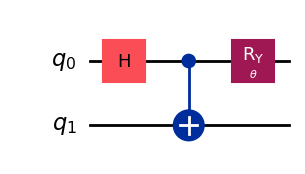

In [3]:

theta = Parameter("$\\theta$")



chsh_circuit = QuantumCircuit(2)

chsh_circuit.h(0)

chsh_circuit.cx(0, 1)

chsh_circuit.ry(theta, 0)

chsh_circuit.draw(output="mpl", idle_wires=False, style="iqp")

### Create a list of phase values to be assigned later

After creating the parameterized CHSH circuit, I will create a list of phase values to be assigned to the circuit in the next step. I can use the following code to create a list of 21 phase values range from $0$ to $2 \pi$ with equal spacing, that is, $0$, $0.1 \pi$, $0.2 \pi$, ..., $1.9 \pi$, $2 \pi$.



In [4]:



number_of_phases = 21
phases = np.linspace(0, 2 * np.pi, number_of_phases)

#Phases need to be expressed as list of lists in order to work
individual_phases = [[ph] for ph in phases]

### Observables

Now I need observables from which to compute the expectation values.  In my case I am looking at orthogonal bases for each qubit, letting the parameterized $Y-$ rotation for the first qubit sweep the measurement basis nearly continuously with respect to the second qubit basis. We will therefore choose the observables $ZZ$, $ZX$, $XZ$, and $XX$.



In [9]:


# <CHSH1> = <AB> - <Ab> + <aB> + <ab> -> <ZZ< - <ZX> + <XZ> + <XX>
observable1 = SparsePauliOp.from_list(
    [('ZZ', 1), ('ZX', -1), ('XZ', 1), ('XX', 1)]

)

# <CHSH2> = <AB> - <Ab> + <aB> - <aB> - <ab> -> <ZZ> + <ZX> - <XZ> + <XX>
observable2 = SparsePauliOp.from_list(
   [('ZZ', 1), ('ZX', -1), ('XZ', -11), ('XX', 1) ]
)


In quantum mechanics, I can't see the whole 'coin' at once while it's spinning; you have to pick a way to look at it.

The Concept I am setting up 'Checkpoints' ($ZZ$$ZZ$, $ZX$$ZX$, $XZ$$XZ$, $XX$$XX$). Think of these as different camera angles. One angle might see if the coins match, another might see how they relate when one is pushed sideways.
The Math: SparsePauliOp is like a Scorecard. We are telling the computer: 'When you look from this angle, if you see this pattern, give it a +1 or a -1.'
The Strategy: By combining these 4 specific 'camera angles,' we can calculate the CHSH Witness—a single number that proves the coins are physically linked (entangled) in a way that regular coins never could be.

## Step 2: Optimize problem for quantum hardware execution



To reduce the total job execution time, V2 primitives only accept circuits and observables that conforms to the instructions and connectivity supported by the target system (referred to as instruction set architecture (ISA) circuits and observables).



### ISA Circuit



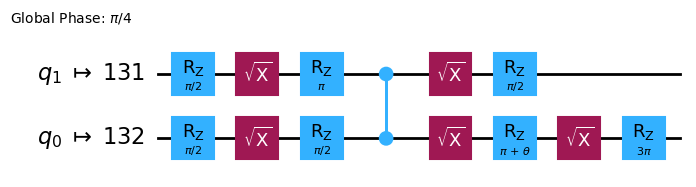

In [10]:
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

chsh_isa_circuit = pm.run(chsh_circuit)
chsh_isa_circuit.draw(output="mpl", idle_wires=False, style="iqp")

target = backend.target: This is like getting the Technical Specs of the specific quantum computer I am using (in this case, ibm_fez). It tells me which qubits are connected and what operations they can actually perform.

pm = generate_preset_pass_manager(...): This creates a Translator/Optimizer. Think of it as a master engineer who knows how to take a high-level blueprint and rewrite it to be as efficient as possible for a specific factory floor. optimization_level=3 means we're asking for the most aggressive improvements possible.

chsh_isa_circuit = pm.run(chsh_circuit): This is the Translation Process. Our 'ideal' circuit is converted into an ISA (Instruction Set Architecture) circuit. It maps our abstract 'qubit 0' and 'qubit 1' to physical wires on the chip and adjusts the gates to match the hardware's native language.

chsh_isa_circuit.draw(...): This shows the Final Blueprint. If you look closely, you'll see the qubits might have different numbers now—those are the specific physical locations on the IBM chip where your experiment will actually run.



### ISA Observables



Similarly, we need to transform the observables to make it backend compatible before running jobs with [`Runtime Estimator V2`](/docs/api/qiskit-ibm-runtime/estimator-v2#run). We can perform the transformation using the `apply_layout` the method of `SparsePauliOp` object.



In [11]:
isa_observable1 = observable1.apply_layout(layout=chsh_isa_circuit.layout)
isa_observable2 = observable2.apply_layout(layout=chsh_isa_circuit.layout)

## Step 3: Execute using Qiskit primitives

In order to execute the entire experiment in one call to the [`Estimator`](https://docs.quantum-computing.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.EstimatorV2).



We can create a [Qiskit Runtime `Estimator`](/docs/api/qiskit-ibm-runtime/estimator-v2) primitive to compute our expectation values. The `EstimatorV2.run()` method takes an iterable of `primitive unified blocs (PUBs)`. Each PUB is an iterable in the format `(circuit, observables, parameter_values: Optional, precision: Optional)`.



In [12]:
# To run on a local simulator:
# Use the StatevectorEstimator from qiskit.primitives instead.

estimator = Estimator(mode=backend)

pub = (
    chsh_isa_circuit,  # ISA circuit
    [[isa_observable1], [isa_observable2]],  # ISA Observables
    individual_phases,  # Parameter values
)

job_result = estimator.run(pubs=[pub]).result()

This is the Execution phase—where we actually fire the lasers at the qubits. Let's break down the mechanics using our Feynman approach:

estimator = Estimator(mode=backend): This initializes our Lab Assistant. By passing mode=backend, we are telling this assistant exactly which machine (ibm_fez) they need to walk over to and operate.

pub = (...): This is a Primitive Unified Bloc, or simply your Work Order. It’s a single package that contains everything the hardware needs to know:

The Blueprint (chsh_isa_circuit)
The Scorecard (the observables)
The Settings (the 21 different angles we prepared)
job_result = estimator.run(pubs=[pub]).result(): This is the Launch.

run sends your Work Order to the IBM Quantum queue.
.result() is the Wait. It tells your computer to stay on the line until the quantum computer finished the task and sends back the raw data.
The Researcher Insight: Instead of running 21 separate jobs, we are running one job with 21 configurations. This is 'Agile' quantum computing—it’s much faster and uses your 'priority' time on the hardware more efficiently.

## Step 4: Post-process and return result in desired classical format

The estimator returns expectation values for both of the observables, $\langle ZZ \rangle - \langle ZX \rangle + \langle XZ \rangle + \langle XX \rangle$ and $\langle ZZ \rangle + \langle ZX \rangle - \langle XZ \rangle + \langle XX \rangle$.



In [13]:
chsh1_est = job_result[0].data.evs[0]
chsh2_est = job_result[0].data.evs[1]

job_result[0]: This is like opening the First Envelope. My job only had one big package (one PUB), so I look inside the very first folder of results.

.data.evs[0] and [1]: This is the Extraction. The .evs stands for Expectation Values. These are the averages of all those camera angles we talked about earlier.

evs[0] is the result for my first scorecard (CHSH1).
evs[1] is the result for my second scorecard (CHSH2).
The Researcher Insight: I've turned thousands of tiny quantum 'clicks' into single, solid numbers. These numbers represent the strength of the correlation between the qubits. If these numbers are higher than 2, I've just proven that quantum mechanics doesn't follow 'common sense' classical rules!

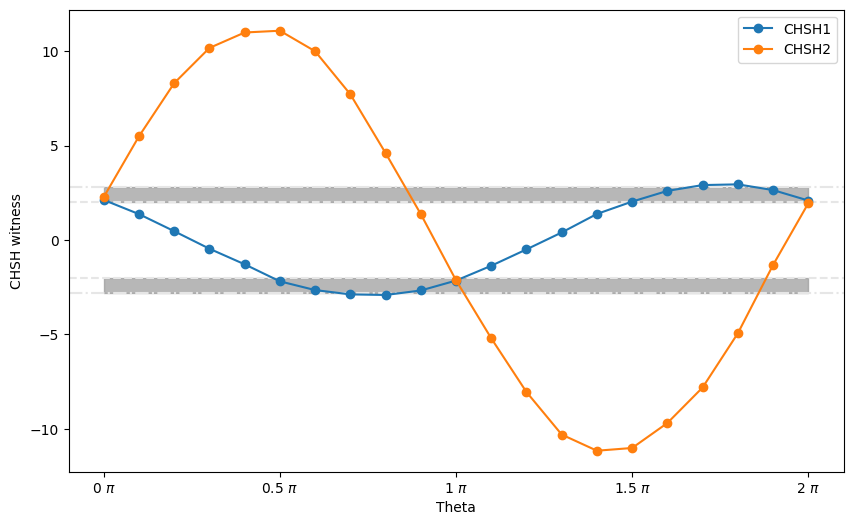

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

# results from hardware
ax.plot(phases / np.pi, chsh1_est, "o-", label="CHSH1", zorder=3)
ax.plot(phases / np.pi, chsh2_est, "o-", label="CHSH2", zorder=3)

# classical bound +-2
ax.axhline(y=2, color="0.9", linestyle="--")
ax.axhline(y=-2, color="0.9", linestyle="--")

# quantum bound, +-2√2
ax.axhline(y=np.sqrt(2) * 2, color="0.9", linestyle="-.")
ax.axhline(y=-np.sqrt(2) * 2, color="0.9", linestyle="-.")
ax.fill_between(phases / np.pi, 2, 2 * np.sqrt(2), color="0.6", alpha=0.7)
ax.fill_between(phases / np.pi, -2, -2 * np.sqrt(2), color="0.6", alpha=0.7)

# set x tick labels to the unit of pi
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
ax.xaxis.set_major_locator(tck.MultipleLocator(base=0.5))

# set labels, and legend
plt.xlabel("Theta")
plt.ylabel("CHSH witness")
plt.legend()
plt.show()

In the figure, the lines and gray areas delimit the bounds; the outer-most (dash-dotted) lines delimit the quantum-bounds ($\pm 2\sqrt{2}$), whereas the inner (dashed) lines delimit the classical bounds ($\pm 2$). You can see that there are regions where the CHSH witness quantities exceeds the classical bounds. Congratulations! You have successfully demonstrated the violation of CHSH inequality in a real quantum system!



## Tutorial survey

Please take this short survey to provide feedback on this tutorial. Your insights will help us improve our content offerings and user experience.

[Link to survey](https://your.feedback.ibm.com/jfe/form/SV_3xxAgm1SF1wGp9k)



© IBM Corp., 2017-2026